# pyCSLDV showcase

**Continuous scanning laser Doppler vibrometry (CSLDV) in Python.**

In a CSLDV measurement the laser spot of the vibrometer sweeps *continuously* over the
vibrating surface instead of dwelling at discrete points. This notebook walks through the
complete workflow supported by `pyCSLDV`:

1. **Scan trajectory design** — Lissajous trajectory and galvo mirror drive signals,
2. **Virtual CSLDV experiment** — the velocity signal an LDV would measure,
3. **ODS reconstruction** — sideband demodulation in a 2D Chebyshev basis,
4. **Validation** — comparison with the exact shape using the modal assurance criterion (MAC),
5. **What the global fit adds** — several modes at once, damping, line scans, several sensors,
6. **Turning a shape onto other axes** — when the specimen is not square to the mirrors.

A measured dataset processed the same way, and compared with the reconstruction of the
original suite, is in [Showcase_measured.ipynb](Showcase_measured.ipynb).

The package can be installed with:

```console
pip install pyCSLDV
```

> **Origin:** pyCSLDV is an independent Python reimplementation of the *CSLDV Vibration
> Measurement & Simulation Suite* by Joshua Bartlett and Pablo Tarazaga (Texas A&M
> University), published under CC-BY-4.0 at
> [zenodo.org/records/22032252](https://zenodo.org/records/22032252)
> (DOI: [10.5281/zenodo.22032252](https://doi.org/10.5281/zenodo.22032252)). The original
> material has been modified; the differences are listed under *Origin and attribution* in
> the README.
>
> **Development note:** the initial Python implementation was written with Claude
> (Anthropic) and has not yet been reviewed by the authors of the original suite. The
> reconstruction is verified against a transcription of the original `ComputeODS.m` in
> `tests/test_matlab_reference.py`. The package is at an alpha stage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pycsldv

pycsldv.__version__

'0.1.0'

## 1. Scan trajectory design

The two galvo mirrors are driven harmonically at frequencies $f_x$ and $f_y$, so the laser
spot traces a Lissajous pattern in normalized coordinates:

$$x(t) = \cos(2 \pi f_x t + \varphi_x), \qquad y(t) = \cos(2 \pi f_y t + \varphi_y).$$

The pattern closes after $1/\gcd(f_x, f_y)$ seconds; measuring for an integer number of
closure periods gives uniform surface coverage.

Lissajous closure period: 5.0 s


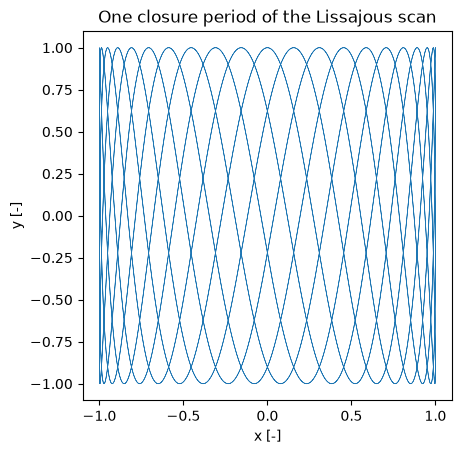

In [2]:
fs = 25000.0        # sampling frequency [Hz]
fx, fy = 1.4, 8.0   # scan frequencies [Hz]

T_scan = pycsldv.scan_period(fx, fy)
print(f'Lissajous closure period: {T_scan} s')

t, x, y = pycsldv.lissajous(fx, fy, n_samples=int(T_scan * fs), fs=fs)
ax = pycsldv.plot_trajectory(x, y)
ax.set_title('One closure period of the Lissajous scan');

In an experiment the normalized trajectory is mapped to mirror drive voltages with a
linear mirror characteristic:

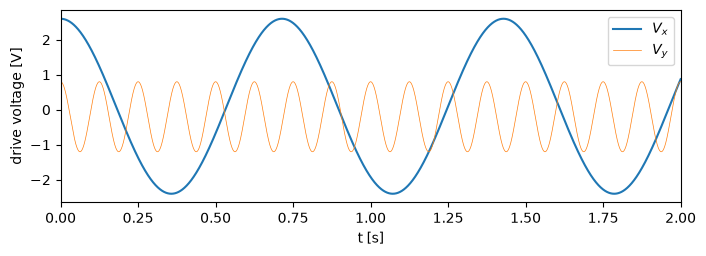

In [3]:
vx, vy = pycsldv.drive_signals(x, y, scale=(2.5, 1.0), offset=(0.1, -0.2))

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t, vx, label='$V_x$')
ax.plot(t, vy, label='$V_y$', linewidth=0.5)
ax.set(xlabel='t [s]', ylabel='drive voltage [V]', xlim=(0, 2))
ax.legend();

## 2. Virtual CSLDV experiment

For a harmonic response at frequency $f_z$ with an operating deflection shape (ODS)
expressed as a 2D Chebyshev series $\sum_{n,m} C_{nm}\, T_n(x)\, T_m(y)$, the measured
velocity is

$$v(t) = \mathrm{Re}\Big\{ \sum_{n,m} C_{nm}\, T_n(x(t))\, T_m(y(t))\, e^{i 2 \pi f_z t} \Big\}.$$

Here we simulate a 10 s measurement of a simply supported plate mode with 5 % additive
noise:

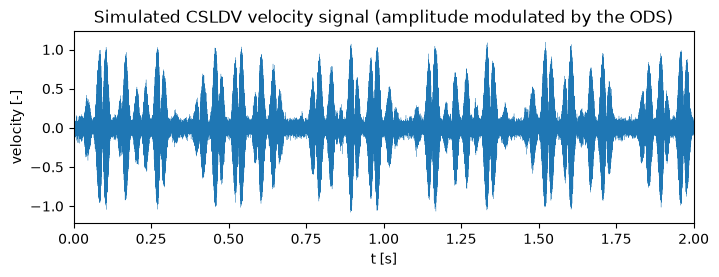

In [4]:
fz = 2000.0                    # response frequency [Hz]
duration = 10.0                # measurement duration [s]
n_samples = int(duration * fs)

shape = pycsldv.plate_mode(3, 2)
rng = np.random.default_rng(0)
t, x, y = pycsldv.lissajous(fx, fy, n_samples, fs)
velocity = pycsldv.simulate_response(shape, fz, x, y, fs, noise_std=0.05, rng=rng)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t, velocity, linewidth=0.2)
ax.set(xlabel='t [s]', ylabel='velocity [-]', xlim=(0, 2),
       title='Simulated CSLDV velocity signal (amplitude modulated by the ODS)');

Because $T_n(\cos\theta) = \cos(n\theta)$, each Chebyshev coefficient appears as a set of
**sidebands** at $f_z \pm n f_x \pm m f_y$ around the response frequency — the deflection
shape is encoded in the spectrum of the single-point measurement:

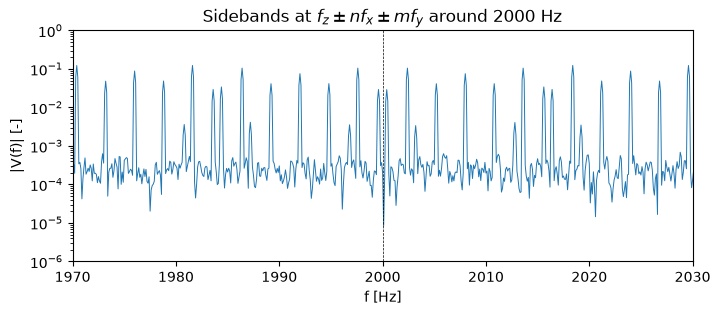

In [5]:
from scipy.signal.windows import hann

w = hann(n_samples, sym=False)
freq = np.fft.rfftfreq(n_samples, 1 / fs)
spectrum = 2 * np.abs(np.fft.rfft(w * velocity)) / w.sum()

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(freq, spectrum, linewidth=0.7)
ax.set(xlabel='f [Hz]', ylabel='|V(f)| [-]', xlim=(fz - 30, fz + 30), ylim=(1e-6, 1),
       title=f'Sidebands at $f_z \\pm n f_x \\pm m f_y$ around {fz:.0f} Hz')
ax.axvline(fz, color='k', linewidth=0.5, linestyle='--');

## 3. ODS reconstruction

pyCSLDV recovers the coefficient matrix $C_{nm}$ in two ways, and they agree on a
measurement like this one.

**`demodulate_ods`** projects the velocity onto each sideband frequency in turn. It takes
the *recorded* mirror signals `x` and `y`, so the mirror phases — the inertial lag of the
galvos — never have to be stated: they are estimated from the signals themselves. The
arbitrary global phase of the response is then removed with `align_phase`.

**`demodulate_ods_2d`** instead fits

$$v(t) = \sum_k \mathrm{Re}\big\{ C^{(k)}(x(t), y(t))\, e^{\lambda_k t} \big\}$$

as one global linear least-squares system. It rebuilds the trajectory from $f_x$, $f_y$ and
the mirror phases `phi_x`, `phi_y`, which therefore have to be supplied — with
`reference_phase(x, fx, fs)` if the mirror feedback was recorded. In exchange it takes
complex poles instead of frequencies, several modes at once, and several sensors, which
§ 5 goes through.

the two reconstructions agree to MAC = 0.999997


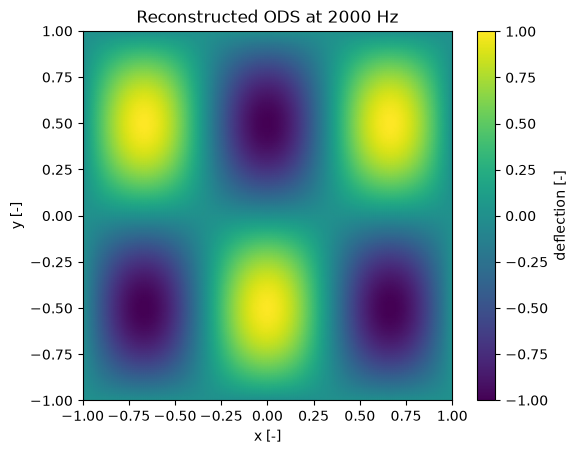

In [6]:
# projection onto the sidebands: the recorded trajectory is the input
C_projected = pycsldv.align_phase(
    pycsldv.demodulate_ods(velocity, x, y, fs, fx, fy, fz, order=8))

# global least-squares fit: the trajectory is rebuilt from fx, fy and the mirror phases
C = pycsldv.align_phase(
    pycsldv.demodulate_ods_2d(velocity, fs, fx, fy, fn=fz, order=8, phi_x=0.0, phi_y=0.0))

print(f'the two reconstructions agree to MAC = '
      f'{pycsldv.mac(pycsldv.evaluate_ods(C_projected, 100)[2].real, pycsldv.evaluate_ods(C, 100)[2].real):.6f}')

ax = pycsldv.plot_ods(C)
ax.set_title(f'Reconstructed ODS at {fz:.0f} Hz');

## 4. Validation against the exact shape

The reconstruction is evaluated on a grid and compared with the exact deflection shape
using the MAC:

MAC(exact, reconstructed) = 1.0000


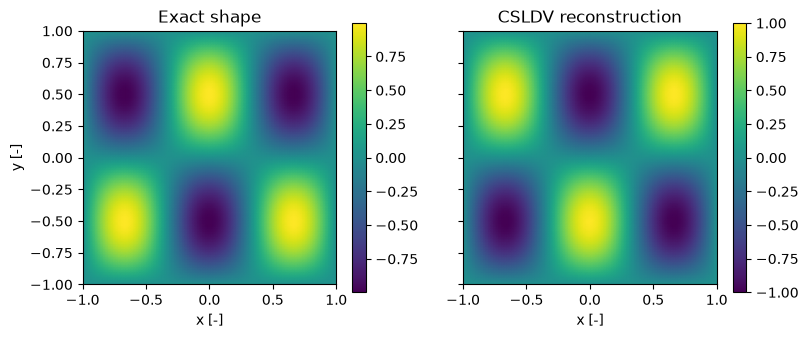

In [7]:
X, Y, Z = pycsldv.evaluate_ods(C, resolution=100)
exact = shape(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, z, title in zip(axes, [exact, Z.real], ['Exact shape', 'CSLDV reconstruction']):
    mesh = ax.pcolormesh(X, Y, z, cmap='viridis', shading='gouraud')
    fig.colorbar(mesh, ax=ax)
    ax.set(title=title, xlabel='x [-]', aspect='equal')
axes[0].set_ylabel('y [-]')

print(f'MAC(exact, reconstructed) = {pycsldv.mac(exact, Z.real):.4f}')

The same virtual experiment repeated for several plate modes shows that the approach
generalizes across shapes of increasing spatial complexity:

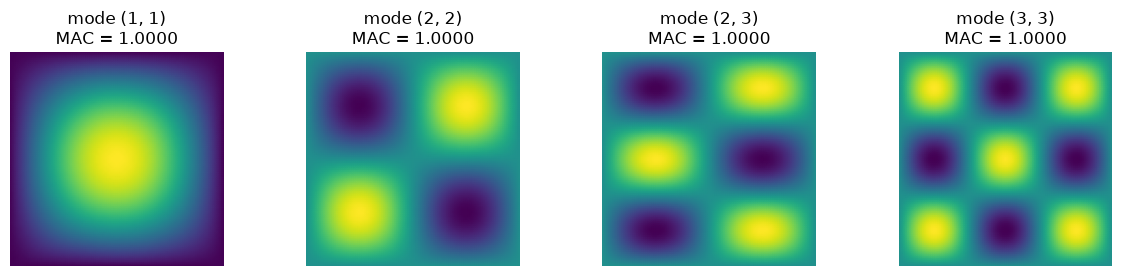

In [8]:
modes = [(1, 1), (2, 2), (2, 3), (3, 3)]

fig, axes = plt.subplots(1, len(modes), figsize=(3 * len(modes), 2.8))
for ax, (p, q) in zip(axes, modes):
    shape_pq = pycsldv.plate_mode(p, q)
    v_pq = pycsldv.simulate_response(shape_pq, fz, x, y, fs, noise_std=0.05, rng=rng)
    C_pq = pycsldv.align_phase(
        pycsldv.demodulate_ods(v_pq, x, y, fs, fx, fy, fz, order=8))
    Xg, Yg, Zg = pycsldv.evaluate_ods(C_pq, resolution=100)
    mac_pq = pycsldv.mac(shape_pq(Xg, Yg), Zg.real)
    ax.pcolormesh(Xg, Yg, Zg.real, cmap='viridis', shading='gouraud')
    ax.set(title=f'mode ({p}, {q})\nMAC = {mac_pq:.4f}', aspect='equal')
    ax.set_axis_off()
fig.tight_layout()

## 5. What the global fit adds

Everything above is one undamped mode, measured by one sensor, on a surface. The sideband
projection is at its best there. `demodulate_ods_2d` solves for the coefficients of every
mode in a single linear system instead, which lifts each of those restrictions in turn.

The design matrix is $n_\mathrm{samples} \times 2\sum_k (P_x^{(k)}+1)(P_y^{(k)}+1)$ and is
formed in full, so it is worth keeping an eye on: a 10 s record at 100 kS/s reconstructed to
order 12 needs about 2.7 GB. The rest of this notebook therefore uses a shorter, more
slowly sampled virtual experiment.

In [9]:
fs_5 = 5000.0                  # sampling frequency [Hz]
fz_5 = 500.0                   # response frequency [Hz]
n_5 = int(10 * fs_5)           # 10 s, two full Lissajous periods

t_5, x_5, y_5 = pycsldv.lissajous(fx, fy, n_5, fs_5)

### 5.1 Several modes in one measurement

A structure excited at several frequencies at once carries one deflection shape per
frequency. Passing a list of frequencies as `fn` fits them together and returns one
coefficient matrix per mode.

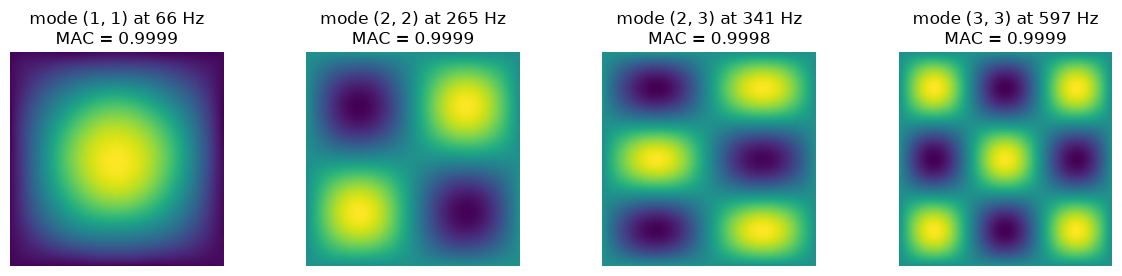

In [10]:
modes = [(1, 1), (2, 2), (2, 3), (3, 3)]
frequencies = [pycsldv.plate_frequency(p, q) for p, q in modes]

multimodal = np.zeros(n_5)
for (p, q), f_pq in zip(modes, frequencies):
    multimodal += pycsldv.simulate_response(pycsldv.plate_mode(p, q), f_pq,
                                            x_5, y_5, fs_5, noise_std=0.05, rng=rng)

coefficients = pycsldv.demodulate_ods_2d(multimodal, fs_5, fx, fy, fn=frequencies, order=8)

fig, axes = plt.subplots(1, len(modes), figsize=(3 * len(modes), 2.8))
for ax, C_pq, (p, q), f_pq in zip(axes, coefficients, modes, frequencies):
    Xg, Yg, Zg = pycsldv.evaluate_ods(pycsldv.align_phase(C_pq), resolution=100)
    mac_pq = pycsldv.mac(pycsldv.plate_mode(p, q)(Xg, Yg), Zg.real)
    ax.pcolormesh(Xg, Yg, Zg.real, cmap='viridis', shading='gouraud')
    ax.set(title=f'mode ({p}, {q}) at {f_pq:.0f} Hz\nMAC = {mac_pq:.4f}', aspect='equal')
    ax.set_axis_off()
fig.tight_layout()

### 5.2 Modes whose sidebands overlap

Fitting the modes together matters when they are close enough for the sidebands of one to
land on the sidebands of another. The spacing that hurts is not "a few Hz" but a multiple
of a scan frequency: with $f_x = 1.4$ Hz, a second mode $2 f_x = 2.8$ Hz away puts its
carrier exactly on the first mode's $n = 2$ sideband, and the projection has no way to tell
the two contributions apart.

In [11]:
first, second = pycsldv.plate_mode(2, 3), pycsldv.plate_mode(3, 2)
f_first = fz_5
f_second = fz_5 + 2 * fx        # exactly on the n = 2 sideband of the first

overlapping = (pycsldv.simulate_response(first, f_first, x_5, y_5, fs_5,
                                         noise_std=0.05, rng=rng)
               + 0.7 * pycsldv.simulate_response(second, f_second, x_5, y_5, fs_5,
                                                 response_phase=1.1, noise_std=0.05, rng=rng))

# one mode at a time, by projection
C_single = pycsldv.align_phase(
    pycsldv.demodulate_ods(overlapping, x_5, y_5, fs_5, fx, fy, f_first, order=8))

# both modes together, by the global fit
C_both = pycsldv.demodulate_ods_2d(overlapping, fs_5, fx, fy,
                                   fn=[f_first, f_second], order=8)

grid = pycsldv.evaluate_ods(C_single, resolution=100)[:2]
exact_first = first(*grid)
print(f'projection, first mode alone : MAC = '
      f'{pycsldv.mac(exact_first, pycsldv.evaluate_ods(C_single, 100)[2].real):.4f}')
for name, C_k, exact in (('first ', C_both[0], exact_first),
                         ('second', C_both[1], second(*grid))):
    z = pycsldv.evaluate_ods(pycsldv.align_phase(C_k), 100)[2].real
    print(f'global fit, {name} mode      : MAC = {pycsldv.mac(exact, z):.4f}')

projection, first mode alone : MAC = 0.9623
global fit, first  mode      : MAC = 0.9999
global fit, second mode      : MAC = 0.9998


### 5.3 Damped, complex modes

A mode measured while it rings down, or one whose points do not all move in phase, is not
described by a real shape at a real frequency. Passing a complex pole
$\lambda = \sigma + i\omega$ as `poles` instead of a frequency as `fn` fits the decaying
envelope together with the shape, and the shape is allowed to be complex.

pole given      : largest coefficient error = 1.09e-14
damping ignored : largest coefficient error = 0.993


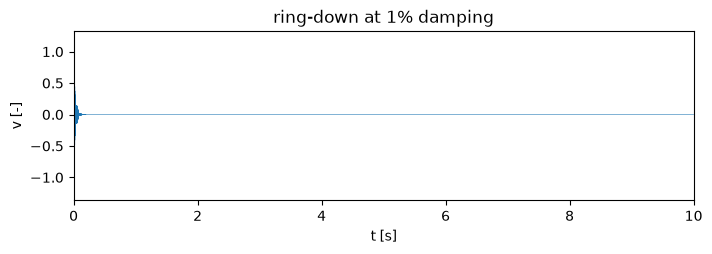

In [12]:
zeta = 0.01                                     # damping ratio [-]
omega = 2 * np.pi * fz_5
pole = -zeta * omega + 1j * omega * np.sqrt(1 - zeta ** 2)

# a shape whose two contributions are 1.2 rad out of phase with each other
C_complex = np.zeros((3, 3), dtype=complex)
C_complex[1, 1] = np.exp(1j * 0.9)
C_complex[2, 0] = 0.5 * np.exp(1j * 2.1)

decaying = (pycsldv.chebyshev_shape(C_complex.real)(x_5, y_5)
            + 1j * pycsldv.chebyshev_shape(C_complex.imag)(x_5, y_5))
decaying = (decaying * np.exp(pole * t_5)).real

with_damping = pycsldv.demodulate_ods_2d(decaying, fs_5, fx, fy, poles=pole, order=2)
without = pycsldv.demodulate_ods_2d(decaying, fs_5, fx, fy, fn=fz_5, order=2)

print(f'pole given      : largest coefficient error = {np.abs(with_damping - C_complex).max():.2e}')
print(f'damping ignored : largest coefficient error = {np.abs(without - C_complex).max():.3f}')

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.plot(t_5, decaying, linewidth=0.4)
ax.set(xlabel='t [s]', ylabel='v [-]', title=f'ring-down at {zeta:.0%} damping', xlim=(0, 10));

### 5.4 The order per mode and per direction

A shape with more structure along one axis than the other, or a set of modes of unequal
complexity, does not need the same polynomial order everywhere. `order` accepts a scalar,
one value per mode, or a pair $(P_x, P_y)$ per mode.

In [13]:
per_direction = pycsldv.demodulate_ods_2d(overlapping, fs_5, fx, fy,
                                          fn=[f_first, f_second],
                                          order=[[3, 8], [8, 3]])
print('coefficient matrices:', [C_k.shape for C_k in per_direction])

coefficient matrices: [(4, 9), (9, 4)]


### 5.5 Several sensors

A three-dimensional scanning vibrometer measures the same scan with several heads. Stacking
the velocity signals as `(locations, n_samples)` fits them all against one design matrix,
which is built once, and returns the coefficients per location.

In [14]:
heads = np.vstack([multimodal, 2.0 * multimodal, -0.5 * multimodal])
per_head = pycsldv.demodulate_ods_2d(heads, fs_5, fx, fy, fn=frequencies, order=6)

print('one matrix per mode:', len(per_head))
print('each of shape (locations, Px + 1, Py + 1):', per_head[0].shape)

one matrix per mode: 4
each of shape (locations, Px + 1, Py + 1): (3, 7, 7)


### 5.6 Line scans

Sweeping the laser along a line rather than over an area gives a one-dimensional shape.
`demodulate_ods_1d` fits the same system in a single Chebyshev variable, and `evaluate_ods`
and `plot_ods` recognize a line from the shape of the coefficients.

MAC = 1.0000


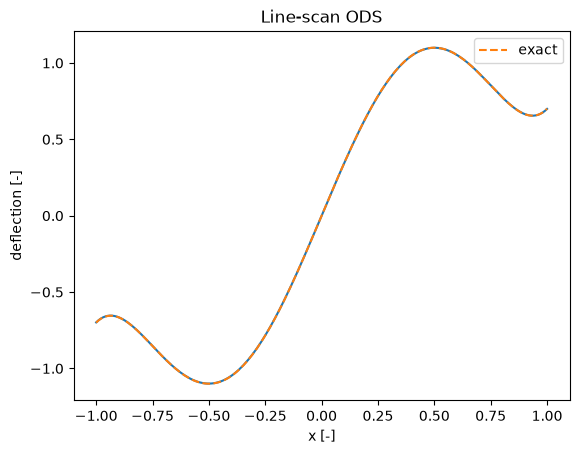

In [15]:
from numpy.polynomial import chebyshev

c_line = np.array([0.0, 1.0, 0.0, -0.5, 0.0, 0.2])
t_line, x_line = pycsldv.sinusoidal_scan(fx, n_5, fs_5)
line_velocity = (chebyshev.chebval(x_line, c_line)
                 * np.cos(2 * np.pi * fz_5 * t_line)) + rng.normal(0.0, 0.05, n_5)

C_line = pycsldv.align_phase(
    pycsldv.demodulate_ods_1d(line_velocity, fs_5, fn=fz_5, fx=fx, order=5))
points, z_line = pycsldv.evaluate_ods(C_line, resolution=200)

print(f'MAC = {pycsldv.mac(chebyshev.chebval(points, c_line), z_line.real):.4f}')
ax = pycsldv.plot_ods(C_line)
ax.plot(points, chebyshev.chebval(points, c_line), '--', label='exact')
ax.legend()
ax.set_title('Line-scan ODS');

## 6. Turning a shape onto other axes

The scan axes need not line up with the edges of the specimen. A shape reconstructed from a
scan that does not follow the specimen comes out tilted, and comparing it with a model — or
with a measurement of the same specimen mounted differently — means turning it first.

`rotate_ods` substitutes the rotated coordinates into the Chebyshev series and expands
again, so the turn is exact rather than a resampling of a grid. `scan_rotation` measures the
angle from the recorded mirror signals, where a rotated scan shows up as each mirror
carrying a little of the other one's scan frequency.

The rotated domain is not the domain the series was fitted on: the corners of the square
turn outside it, where the series extrapolates. `rotate_ods` warns when that overhang
exceeds 5 %, and the comparison below therefore looks at the interior.

/home/jankoslavic/_d/cld/ContinuousScanningLDV/pyCSLDV/pycsldv/demodulate.py:557: UserWarning: the rotated domain extends 28 % beyond [-1, 1], where the Chebyshev series extrapolates; the shape near the corners is not to be trusted.
  warnings.warn(


scan_rotation recovers 20.00 deg from the mirror signals


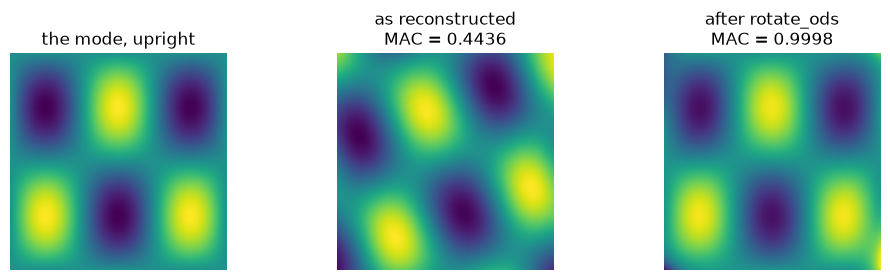

In [16]:
angle = np.deg2rad(20.0)

def mounted_askew(x, y):
    return pycsldv.plate_mode(3, 2)(x * np.cos(angle) + y * np.sin(angle),
                                    -x * np.sin(angle) + y * np.cos(angle))

askew = pycsldv.simulate_response(mounted_askew, fz_5, x_5, y_5, fs_5,
                                  noise_std=0.05, rng=rng)
C_askew = pycsldv.align_phase(
    pycsldv.demodulate_ods_2d(askew, fs_5, fx, fy, fn=fz_5, order=8))
C_turned = pycsldv.rotate_ods(C_askew, angle)

# the angle can also be read off the mirror feedback of a rotated scan
x_rotated = x_5 * np.cos(angle) - y_5 * np.sin(angle)
y_rotated = x_5 * np.sin(angle) + y_5 * np.cos(angle)
print(f'scan_rotation recovers {np.degrees(pycsldv.scan_rotation(x_rotated, y_rotated, fx, fy, fs_5)):.2f}'
      f' deg from the mirror signals')

upright = pycsldv.plate_mode(3, 2)
fig, axes = plt.subplots(1, 3, figsize=(10, 2.9))
Xg, Yg, _ = pycsldv.evaluate_ods(C_askew, resolution=100)
interior = np.hypot(Xg, Yg) < 0.7
panels = [(upright(Xg, Yg), 'the mode, upright', None),
          (pycsldv.evaluate_ods(C_askew, 100)[2].real, 'as reconstructed', C_askew),
          (pycsldv.evaluate_ods(C_turned, 100)[2].real, 'after rotate_ods', C_turned)]
for ax, (z, title, C_k) in zip(axes, panels):
    ax.pcolormesh(Xg, Yg, z, cmap='viridis', shading='gouraud')
    if C_k is not None:
        title += f'\nMAC = {pycsldv.mac(upright(Xg, Yg)[interior], z[interior]):.4f}'
    ax.set(title=title, aspect='equal')
    ax.set_axis_off()
fig.tight_layout()

## References

- J. Bartlett, P. Tarazaga: *Continuous Scanning Laser Doppler Vibrometry (CSLDV)
  Vibration Measurement & Simulation Suite*, version 1.1, Zenodo, 2026, DOI:
  [10.5281/zenodo.22032252](https://doi.org/10.5281/zenodo.22032252).
- A. B. Stanbridge, D. J. Ewins: *Modal testing using a scanning laser Doppler vibrometer*,
  Mechanical Systems and Signal Processing 13(2), 1999, 255–270.
- S. Rothberg et al.: *An international review of laser Doppler vibrometry: Making light
  work of vibration measurement*, Optics and Lasers in Engineering 99, 2017, 11–22.